In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

from imblearn.over_sampling import SMOTE


In [ ]:
df = pd.read_csv("Telco_Cusomer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:

df.drop('customerID', axis=1, inplace=True)


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


/tmp/ipython-input-2048788834.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:

df['AvgRevenue'] = df['TotalCharges'] / (df['tenure'] + 1)


df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 36, 72],
    labels=['New', 'Mid', 'Loyal']
).astype(str)

services = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]

df['ServiceCount'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)


df['ContractRisk'] = df['Contract'].map({
    'Month-to-month': 3,
    'One year': 2,
    'Two year': 1
})

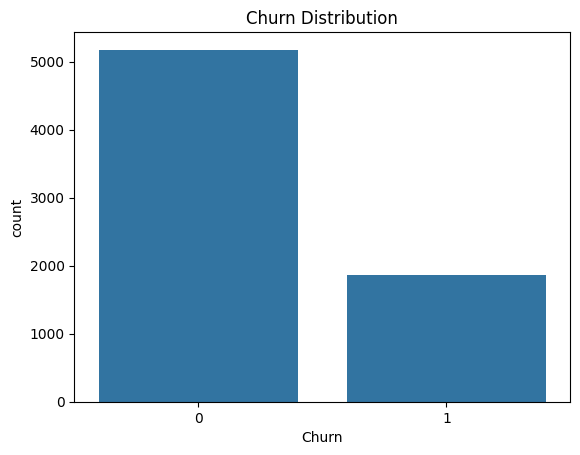

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


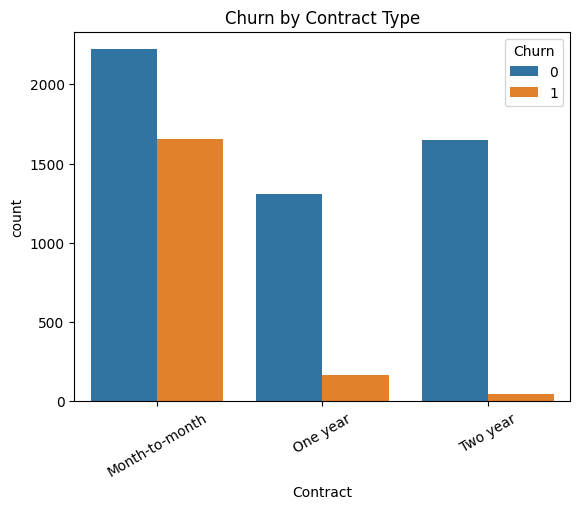

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=30)
plt.show()


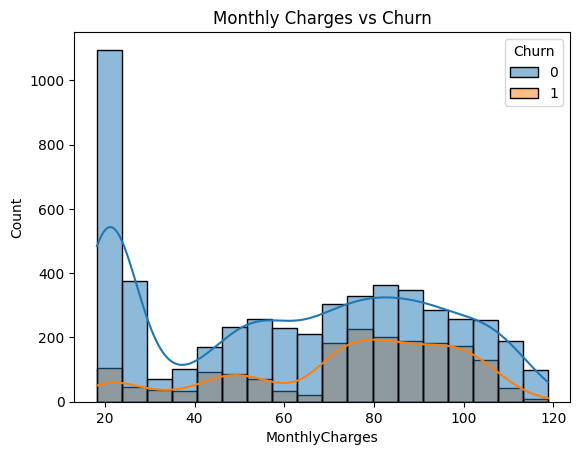

In [ ]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)
plt.title("Monthly Charges vs Churn")
plt.show()


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']


cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)


smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_pre, y_train)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm, y_train_sm)


LogisticRegression(max_iter=1000)

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_sm, y_train_sm)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
gb = GradientBoostingClassifier()
gb.fit(X_train_sm, y_train_sm)


GradientBoostingClassifier()

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

results = pd.DataFrame({
    "Logistic Regression": evaluate_model(lr, X_test_pre, y_test),
    "Random Forest": evaluate_model(rf, X_test_pre, y_test),
    "Gradient Boosting": evaluate_model(gb, X_test_pre, y_test)
})

results


,Logistic Regression,Random Forest,Gradient Boosting
Accuracy,0.743080,0.772179,0.770050
Precision,0.510453,0.572207,0.558140
Recall,0.783422,0.561497,0.641711
F1,0.618143,0.566802,0.597015
ROC_AUC,0.844062,0.822825,0.840068


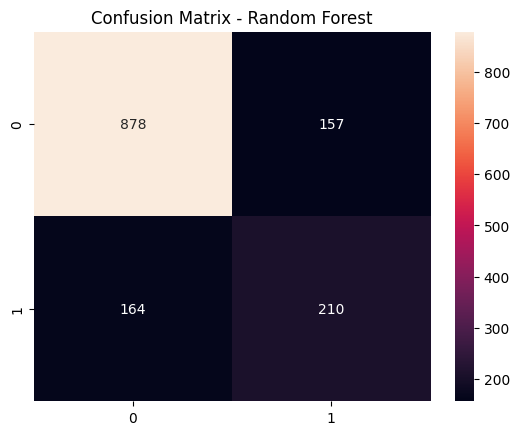

In [ ]:
cm = confusion_matrix(y_test, rf.predict(X_test_pre))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()


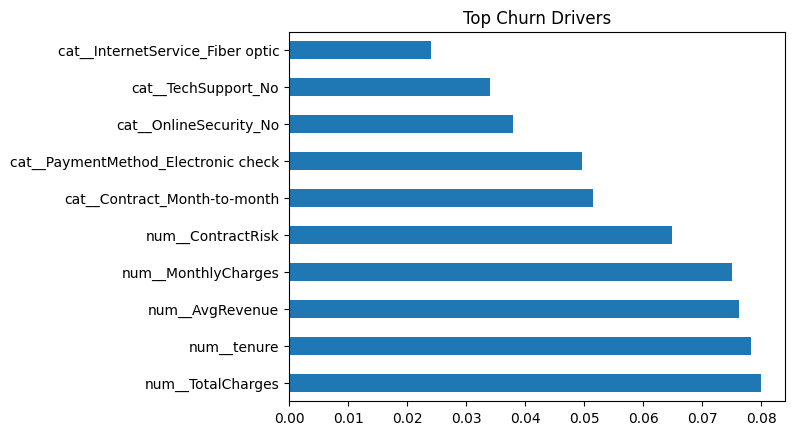

In [ ]:
importances = rf.feature_importances_
feature_names = preprocessor.get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:10]
feat_imp.plot(kind='barh')
plt.title("Top Churn Drivers")
plt.show()


In [ ]:
import pickle

# Save model
with open("churn_model.pkl", "wb") as f:
    pickle.dump(rf, f)

# Save preprocessor
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)
